# M1 — Data & Conventions for the Elastic-RT Forward Model

**retrieve-or-bust · branch `rt-elastic-prototype` · 2026-08-01**

Milestone M1 is where `robust/rt/` stops being a scaffold. Three modules got real
bodies, and the first numbers entered the repo:

| Module | What it now holds |
|---|---|
| `robust/rt/conventions.py` | `Rrs↔rrs` (A = 0.52, B = 1.7), the 81-band grid, `bb_w(λ)`, boundary validators |
| `robust/rt/types.py` | the `IOPs` / `PhaseParams` / `Geometry` pytrees |
| `robust/rt/data/l23.py` | the one-call L23 loader, `B_p`, and the two seeded held-out splits |

This notebook is about the **decisions**, not the call signatures. Four questions,
in order: why fit in `rrs` rather than `Rrs`; why `bb_w` is kept apart from
`bb_p`; what `B_p` actually looks like in the reference data; and what the two
held-out splits protect against.

M0's notebook — [`rt_elastic_coding_1.ipynb`](rt_elastic_coding_1.ipynb) — already
covers the JAX side (autodiff, why float64 matters for the M2 gradient gate, the
scaffold). Nothing here repeats it.

**Companions.** [`design/rt_elastic_model.md`](../../design/rt_elastic_model.md)
(design) · [`design/rt_elastic_model_coding_plan.md`](../../design/rt_elastic_model_coding_plan.md)
(milestones) · [`design/rt_elastic_implementation.md`](../../design/rt_elastic_implementation.md)
(what was built) · [`claude_prompts/RT/rt_elastic_coding_prompt_2.md`](../../claude_prompts/RT/rt_elastic_coding_prompt_2.md)
(the M1 prompt, work log, and Q&A).

In [1]:
import importlib
import sys
from pathlib import Path

# `robust` need not be pip-installed; walk up to the repo root either way.
REPO = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "robust" / "__init__.py").exists()
)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import jax
import jax.numpy as jnp
import numpy as np

from robust.rt import conventions as C
from robust.rt import types as T
from robust.rt.data import l23 as L

print(f"repo   : {REPO}")
print(f"jax    : {jax.__version__} on {jax.default_backend()}")
print(f"grid   : {C.N_WAVE} bands, {C.WAVE_MIN:.0f}-{C.WAVE_MAX:.0f} nm, {C.WAVE_STEP:.0f} nm apart")

repo   : /Users/xavier/Oceanography/python/retrieve-or-bust
jax    : 0.11.0 on cpu
grid   : 81 bands, 350-750 nm, 5 nm apart


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# The house figure style from M0's notebook, unchanged so the two read as one set.
INK, INK_MUTED, GRID = "#1a1a1a", "#5c5c5c", "#dcdcdc"
C_A, C_B = "#0072B2", "#D55E00"  # CVD-checked pair: OKLab dE 28.8-44.8 (>= 8)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10.5,
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white", "axes.facecolor": "white",
})

# A single-hue sequential ramp, truncated so the palest line still has contrast.
BLUES = mpl.colors.LinearSegmentedColormap.from_list(
    "blues_trunc", plt.cm.Blues(np.linspace(0.30, 0.98, 256))
)
print("style set")

style set


## 1. Why the fitting space is `rrs`, not `Rrs`

`Rrs` is what a satellite measures above the water. Every model in this lineage —
Gordon, PR05, O25, ZTT — is formulated for the **subsurface** reflectance `rrs`,
because that is where the radiative transfer happens; the air–water interface is a
separate, largely geometric problem. The two are related by

$$r_{rs} = \frac{R_{rs}}{A + B\,R_{rs}}, \qquad
  R_{rs} = \frac{A\,r_{rs}}{1 - B\,r_{rs}}, \qquad A = 0.52,\; B = 1.7$$

(Lee et al. 2002). So `conventions.py` owns exactly one interface convention, and
everything downstream inherits it. Two things follow, and both are asserted rather
than assumed.

In [3]:
print("A, B in robust.rt.conventions :", C.A_RRS, C.B_RRS)
try:
    import bing.rt as bing_rt
except ImportError:
    print("bing not installed here - the equality is asserted by the test suite")
else:
    print("A, B in bing.rt               :", bing_rt.A_Rrs, bing_rt.B_Rrs)
    print("agree                         :",
          (C.A_RRS, C.B_RRS) == (bing_rt.A_Rrs, bing_rt.B_Rrs))

A, B in robust.rt.conventions : 0.52 1.7


A, B in bing.rt               : 0.52 1.7
agree                         : True


**They match BING.** Fixing A and B only buys something if the *other* package we
share `rrs` with agrees — otherwise two "rrs" numbers in the same project mean
different things. A test asserts the equality, so it cannot drift silently.

**The conversion is non-linear, and that is the point.** If `Rrs → rrs` were a
constant scaling, the choice of fitting space would be cosmetic — a relative error
in one would be the same relative error in the other. It is not: the denominator
`1 − B·rrs` grows the ratio as reflectance rises.

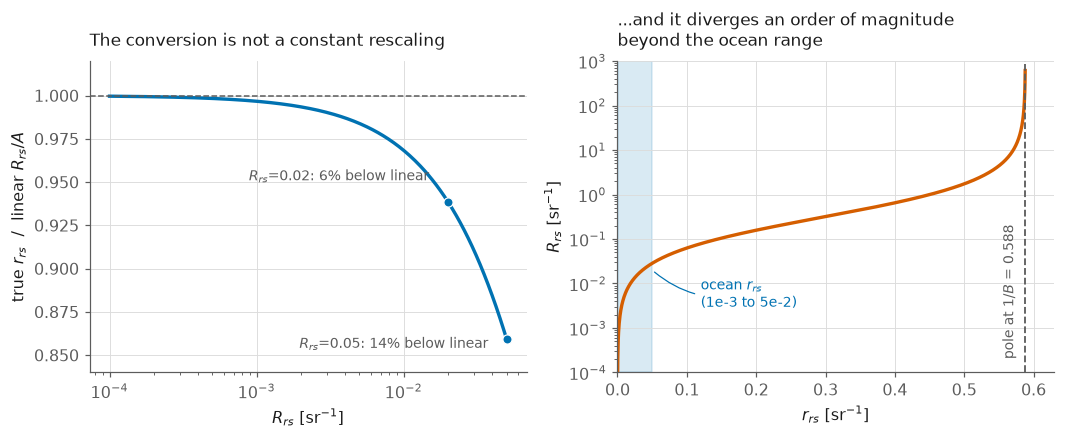

In [4]:
Rrs = np.logspace(-4, -1.3, 300)
ratio = np.asarray(C.Rrs_to_rrs(jnp.asarray(Rrs))) / (Rrs / C.A_RRS)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(9.8, 4.1))

# --- left: how far the true conversion departs from a linear one ---
ax_l.plot(Rrs, ratio, color=C_A, lw=2.2)
ax_l.set_xscale("log")
ax_l.axhline(1.0, color=INK_MUTED, lw=1, ls="--")
for target, dy in ((0.02, 14), (0.05, -6)):
    i = int(np.argmin(np.abs(Rrs - target)))
    ax_l.plot([Rrs[i]], [ratio[i]], "o", color=C_A, ms=6,
              markeredgecolor="white", markeredgewidth=0.8, zorder=3)
    ax_l.annotate(f"$R_{{rs}}$={target:g}: {100 * (1 - ratio[i]):.0f}% below linear",
                  xy=(Rrs[i], ratio[i]), xytext=(-12, dy),
                  textcoords="offset points", color=INK_MUTED, fontsize=9, ha="right")
ax_l.set_xlabel("$R_{rs}$ [sr$^{-1}$]")
ax_l.set_ylabel("true $r_{rs}$  /  linear $R_{rs}/A$")
ax_l.set_title("The conversion is not a constant rescaling", fontsize=11, loc="left", pad=10)
ax_l.set_ylim(0.84, 1.02)

# --- right: the pole, on a log axis so the divergence is actually visible ---
rrs_wide = np.linspace(1e-4, 0.9995 * C.RRS_POLE, 2000)
ax_r.plot(rrs_wide, np.asarray(C.rrs_to_Rrs(jnp.asarray(rrs_wide))), color=C_B, lw=2.2)
ax_r.set_yscale("log")
ax_r.axvline(C.RRS_POLE, color=INK_MUTED, lw=1.2, ls="--")
ax_r.text(C.RRS_POLE - 0.012, 2e-4, f"pole at $1/B$ = {C.RRS_POLE:.3f}",
          color=INK_MUTED, fontsize=9, ha="right", va="bottom", rotation=90)
ax_r.axvspan(1e-3, 5e-2, color=C_A, alpha=0.15)
ax_r.annotate("ocean $r_{rs}$\n(1e-3 to 5e-2)", xy=(0.05, 2e-2), xytext=(0.12, 3e-3),
              color=C_A, fontsize=9,
              arrowprops=dict(arrowstyle="-", color=C_A, lw=0.8,
                              connectionstyle="arc3,rad=-0.25"))
ax_r.set_xlabel("$r_{rs}$ [sr$^{-1}$]")
ax_r.set_ylabel("$R_{rs}$ [sr$^{-1}$]")
ax_r.set_xlim(0, 0.63)
ax_r.set_ylim(1e-4, 1e3)
ax_r.set_title("...and it diverges an order of magnitude\nbeyond the ocean range",
               fontsize=11, loc="left", pad=10)

fig.tight_layout()
plt.show()

Left: the ratio of the true `rrs` to a naive linear rescaling `Rrs/A`. It is 6%
below linear at `Rrs` = 0.02 and 14% below at 0.05, so relative errors are **not**
interchangeable between the two spaces — which is why the validation protocol (§6 of the design)
specifies rRMS *in `rrs` space*, and why the conversion lives in one module rather
than being re-derived per model.

Right: `rrs → Rrs` diverges at `rrs = 1/B ≈ 0.588` and returns *negative* `Rrs`
past it. Real ocean `rrs` is 1e-3 to 5e-2, more than a decade below the pole, so the only
way to get there is a unit error — an `Rrs` in the wrong units, say, fed in as
`rrs`. `conventions.check_rrs` looks for exactly that and says "check the units",
because the alternative is an inexplicable negative reflectance surfacing at M3.

## 2. Why `bb_w` is kept apart from `bb_p`

`IOPs` stores `a`, `bb_w`, and `bb_p` — not `a` and a single `bb`. The design calls
the water/particle split "load-bearing", and the reason is quantitative: pure water
is a *large* fraction of total backscatter in the blue and a negligible one in the
red.

In [5]:
# The committed 50-scene fixture: real L23 numbers, no $OS_COLOR needed.
batch_small = L.load_batch(reader=L.npz_reader(REPO / "robust/tests/files/l23_small.npz"))
wave = np.asarray(batch_small.wave)
bb_w = np.asarray(batch_small.iops.bb_w)[0]
bb_p_med = np.median(np.asarray(batch_small.iops.bb_p), axis=0)

share_all = np.asarray(batch_small.iops.bb_w) / (
    np.asarray(batch_small.iops.bb_w) + np.asarray(batch_small.iops.bb_p)
)

print("  λ [nm]    bb_w        bb_p (median)   water share of bb (median, and range over scenes)")
for lam in (400, 440, 550, 650, 750):
    i = int(np.argmin(abs(wave - lam)))
    s = share_all[:, i]
    print(f"   {lam:3d}    {bb_w[i]:.3e}   {bb_p_med[i]:.3e}      "
          f"{np.median(s):6.1%}   ({s.min():.0%} - {s.max():.0%})")

  λ [nm]    bb_w        bb_p (median)   water share of bb (median, and range over scenes)
   400    3.305e-03   1.279e-03       72.1%   (37% - 86%)
   440    2.196e-03   1.099e-03       66.7%   (30% - 84%)
   550    8.557e-04   8.617e-04       49.8%   (16% - 70%)
   650    4.264e-04   6.920e-04       38.1%   (10% - 58%)
   750    2.357e-04   5.786e-04       29.0%   (6% - 48%)


The numbers are more emphatic than I expected before running it: for the median
L23 scene **water contributes ~72% of total backscatter at 400 nm**, about half at
550 nm, and still ~29% at 750 nm. Across scenes the water share at 400 nm ranges
from 37% (turbid) to 87% (clear). So `bb_w` is not a small correction to be
absorbed — over much of the spectrum it is the *larger* term.

Sum the two into a single `bb` and an inversion has to spend capacity re-learning a
quantity we already know exactly, while any error in the water part lands directly
on the particle part — which is the thing we actually want to retrieve.

Keeping them separate is also free: L23 reports `bb` and `bbnw`, so the loader
takes `bb_w = bb − bbnw` and `bb_p = bbnw` straight from the file. `conventions.py`
additionally ships `bb_w(λ)` as an embedded 81-value table for callers who do
*not* have L23 in hand (an inversion at M5, say).

Two things worth knowing about that table, both found while building it:

- Its provenance is L23 itself, and the difference `bb − bbnw` is **constant to
  1.6e-7 relative across all 3320 scenes, all three zeniths, and both X=1 and
  X=4** — so a single table is legitimate. `bing` and `ocpy` both compute the same
  quantity at an *arbitrary* scene index (0 and 170, the latter commented "Random
  choie") without checking that it does not matter. It does not — but that is now
  a test rather than a coincidence.
- The physically-parameterised alternative is a dead end today: both packages carry
  a TODO pointing at Zhang, Hu & He (2009), and
  `ocpy.water.scattering.betasw_ZHH2009` raises
  `"THIS IS NOT SUCCESFULLY CONVERTED YET"` on its first line — an unfinished
  MATLAB port. It becomes relevant at M5, when new HydroLight runs may not share
  L23's water column.

## 3. What `B_p` actually looks like

`B_p = b_{bp} / b_p` is the particulate **backscattering ratio**: of all the light
particles scatter, the fraction sent backward. It is the design's explicit
phase-function parameter (§4.2) — the one scalar to which the fuller
descriptors reduce at leading order, and the reason this model can claim
phase-function dependence at all rather than burying it in fitted constants.

The design expects ~[0.004, 0.03]. M0 measured it at 440 nm only, so prompt 2
asked the obvious follow-up: **does that range hold at every wavelength, or does it
fail in the UV or the far red?**

In [6]:
batch_full = None
B_p_full = None
try:
    batch_full = L.load_batch()  # all 3 zeniths x 3320 scenes
    B_p_full = np.asarray(batch_full.phase_params.B_p)
    print(f"full release: {B_p_full.shape[0]} samples x {B_p_full.shape[1]} bands "
          f"= {B_p_full.size:,} values")
    lo, hi = L.B_P_EXPECTED
    inside = (B_p_full >= lo) & (B_p_full <= hi)
    print(f"inside the design band [{lo}, {hi}]: {100 * inside.mean():.4f}%")
    print(f"observed range: [{B_p_full.min():.5f}, {B_p_full.max():.5f}]")
    print(f"spanned factor: {B_p_full.max() / B_p_full.min():.2f}x "
          f"(the design band spans {hi / lo:.1f}x)")
except Exception as exc:
    print(f"L23 not mounted ($OS_COLOR) - skipping the full-release view: {exc}")

full release: 9960 samples x 81 bands = 806,760 values
inside the design band [0.004, 0.03]: 100.0000%
observed range: [0.01026, 0.01800]
spanned factor: 1.75x (the design band spans 7.5x)


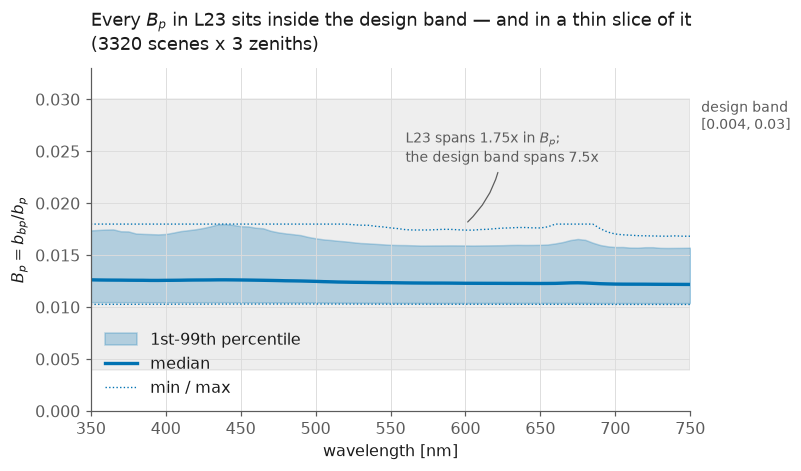

In [7]:
source = B_p_full if B_p_full is not None else np.asarray(batch_small.phase_params.B_p)
label = "3320 scenes x 3 zeniths" if B_p_full is not None else "50-scene cached fixture"

lo, hi = L.B_P_EXPECTED
p01, p50, p99 = np.percentile(source, [1, 50, 99], axis=0)

fig, ax = plt.subplots(figsize=(7.4, 4.4))

ax.axhspan(lo, hi, color=INK_MUTED, alpha=0.10)
ax.text(752, hi, f"  design band\n  [{lo}, {hi}]", color=INK_MUTED, fontsize=9, va="top")

ax.fill_between(wave, p01, p99, color=C_A, alpha=0.25, label="1st-99th percentile")
ax.plot(wave, p50, color=C_A, lw=2.2, label="median")
ax.plot(wave, source.min(axis=0), color=C_A, lw=0.9, ls=":", label="min / max")
ax.plot(wave, source.max(axis=0), color=C_A, lw=0.9, ls=":")

ax.annotate(
    f"L23 spans {source.max() / source.min():.2f}x in $B_p$;\n"
    f"the design band spans {hi / lo:.1f}x",
    xy=(600, source.max()), xytext=(560, 0.024), color=INK_MUTED, fontsize=9,
    arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=0.8, connectionstyle="arc3,rad=-0.2"),
)

ax.set_xlabel("wavelength [nm]")
ax.set_ylabel("$B_p = b_{bp} / b_p$")
ax.set_title(f"Every $B_p$ in L23 sits inside the design band — and in a thin slice of it\n"
             f"({label})", fontsize=11.5, loc="left", pad=12)
ax.set_xlim(wave.min(), wave.max())
ax.set_ylim(0, 0.033)
ax.legend(loc="lower left")
fig.tight_layout()
plt.show()

**The answer to prompt 2's question: the range holds everywhere.** 100% of the
268,920 (scene, wavelength) values sit inside the design band at every one of the
81 bands — no UV or far-red excursion — so the range assert needs no
wavelength-dependent escape hatch. The test checks it *per band*, not just
globally, because a narrow band-specific excursion would otherwise hide inside a
global min/max.

**But the same figure carries a caveat that matters more than the reassurance.**
L23 occupies a factor of ~1.75 in `B_p` (0.0103–0.0180) where the design's nominal
band spans ~7.5. The reference set holds the phase function *fixed* — one
Fournier–Forand shape — so the small spread you see is variation in particle load,
not in phase-function shape. Which means the week-1 prototype can demonstrate that
the model *accepts* an explicit phase-function parameter, and can fit the narrow
range present, but **cannot** demonstrate that it generalises across
phase-function shape. That is exactly what M5's new HydroLight runs are for, and
it is an honest bound on what the M4 gate will prove.

Note also that `B_p` is not flat in λ (it falls ~7% from 350 to 750 nm), so it is
carried as a spectrum rather than collapsed to a per-scene scalar. `PhaseParams`
accepts either.

## 4. What the two held-out splits protect against

The M4 gate requires the hybrid to beat standard Gordon on **both** held-out
splits (coding plan CQ6). They guard against different failures, which is why both
exist.

In [8]:
target = batch_full if batch_full is not None else batch_small
splits = L.make_splits(target)

print(f"batch: {target.n_sample} samples "
      f"({len(L.ZENITHS)} zeniths x {target.n_sample // len(L.ZENITHS)} scenes)")
print(f"seed : {L.SPLIT_SEED} (fixed forever; changing it invalidates the record)")
print()
print(f"random split   : {splits.scene_train.sum():5d} train / "
      f"{splits.scene_test.sum():5d} test samples "
      f"({splits.test_scenes.size} held-out scenes)")
print(f"zenith split   : {splits.zenith_train.sum():5d} train / "
      f"{splits.zenith_test.sum():5d} test samples "
      f"(train 0/30 deg, test {L.HELD_OUT_ZENITH} deg)")
print()
train_scenes = set(target.scene[splits.scene_train].tolist())
test_scenes = set(target.scene[splits.scene_test].tolist())
print(f"scene overlap between train and test: {len(train_scenes & test_scenes)}")

batch: 9960 samples (3 zeniths x 3320 scenes)
seed : 23 (fixed forever; changing it invalidates the record)

random split   :  7968 train /  1992 test samples (664 held-out scenes)
zenith split   :  6640 train /  3320 test samples (train 0/30 deg, test 60 deg)

scene overlap between train and test: 0


That last line is the one that matters. **The split is by *scene*, not by sample.**

Each water body appears three times in the batch — once per solar zenith. A
per-sample split would put the same IOPs in both train and test at different sun
angles, so the model could be tested on a water body it had already fitted. Every
held-out number would then be optimistic, and the M4 gate would be quietly
measuring memorisation instead of generalisation. `make_splits` therefore draws
scenes and expands to a sample mask, and a test asserts the two scene sets are
disjoint. Because the whole gate rests on it, that test runs against a synthetic
batch too — so it is checked in CI, with no dataset present.

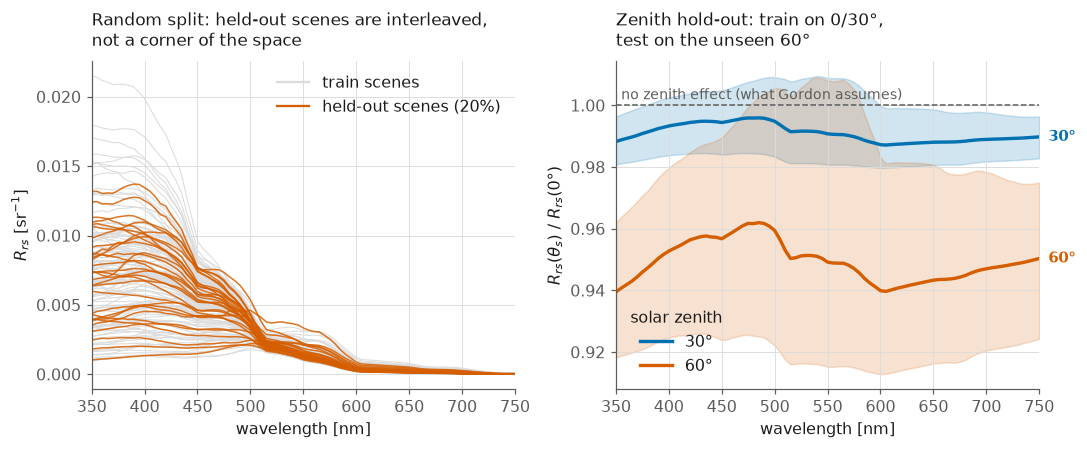

In [9]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(10.0, 4.2))

# --- Left: the random scene split, drawn as spectra ---
Rrs_all = np.asarray(target.Rrs)
at_zero = target.zenith == 0.0
tr = np.flatnonzero(at_zero & splits.scene_train)
te = np.flatnonzero(at_zero & splits.scene_test)
rng = np.random.default_rng(0)
for i in rng.choice(tr, size=min(120, tr.size), replace=False):
    ax_l.plot(wave, Rrs_all[i], color=GRID, lw=0.7, zorder=1)
for i in rng.choice(te, size=min(30, te.size), replace=False):
    ax_l.plot(wave, Rrs_all[i], color=C_B, lw=1.0, alpha=0.85, zorder=2)
ax_l.plot([], [], color=GRID, lw=1.5, label="train scenes")
ax_l.plot([], [], color=C_B, lw=1.5, label=f"held-out scenes ({int(100 * L.TEST_FRACTION)}%)")
ax_l.set_xlabel("wavelength [nm]")
ax_l.set_ylabel("$R_{rs}$ [sr$^{-1}$]")
ax_l.set_title("Random split: held-out scenes are interleaved,\nnot a corner of the space",
               fontsize=11, loc="left", pad=10)
ax_l.set_xlim(wave.min(), wave.max())
ax_l.legend(loc="upper right")

# --- Right: the zenith hold-out, as the ratio the model must extrapolate ---
n_scene = target.n_sample // len(L.ZENITHS)
R = Rrs_all.reshape(len(L.ZENITHS), n_scene, C.N_WAVE)
for k, (zen, colour) in enumerate([(30, C_A), (60, C_B)], start=1):
    ratio = R[k] / R[0]
    ax_r.plot(wave, np.median(ratio, axis=0), color=colour, lw=2.2, label=f"{zen}\u00b0")
    ax_r.fill_between(wave, *np.percentile(ratio, [5, 95], axis=0), color=colour, alpha=0.18)
    ax_r.annotate(f"{zen}\u00b0", xy=(wave[-1], np.median(ratio[:, -1])),
                  xytext=(6, 0), textcoords="offset points", color=colour,
                  fontsize=10, va="center", fontweight="bold")
ax_r.axhline(1.0, color=INK_MUTED, lw=1, ls="--")
ax_r.text(355, 1.002, "no zenith effect (what Gordon assumes)", color=INK_MUTED, fontsize=9)
ax_r.set_xlabel("wavelength [nm]")
ax_r.set_ylabel("$R_{rs}(\\theta_s)$ / $R_{rs}$(0\u00b0)")
ax_r.set_title("Zenith hold-out: train on 0/30\u00b0,\ntest on the unseen 60\u00b0",
               fontsize=11, loc="left", pad=10)
ax_r.set_xlim(wave.min(), wave.max())
ax_r.legend(loc="lower left", title="solar zenith")

fig.tight_layout()
plt.show()

**Left — the random scene split** holds out 20% of water bodies. Their spectra are
interleaved with the training set rather than occupying an edge of the space, which
is what makes it a fair test of interpolation across IOPs: the model sees the same
kind of water, just not those particular ones.

**Right — the zenith hold-out** is the harder and more interesting gate. It shows
the quantity being held out: `Rrs` falls by a median 5.1% at 60° and 1.0% at 30°,
with real wavelength structure. The dashed line at 1.0 is what **standard Gordon
assumes** — it has no solar-zenith dependence whatsoever, so it necessarily sits on
that line at every angle. A model that captures even part of the 60° offset should
therefore beat it on this split, and that is precisely the comparison M3 and M4
run.

It also shows how narrow the geometry lever is: three angles, of which we train on
two. Getting 60° right by *interpolating* 0° and 30° is not available — 60° is an
extrapolation beyond both.

## 5. The API in one cell

Everything above goes through the same three calls M2 and M3 will use.

In [10]:
train = L.select(target, splits.scene_train)
held = L.select(target, splits.zenith_test)

print(f"train : {train.n_sample:5d} samples, zeniths {sorted(set(train.zenith.tolist()))}")
print(f"held  : {held.n_sample:5d} samples, zeniths {sorted(set(held.zenith.tolist()))}")
print()
print("model inputs are pytrees, so jax transforms traverse them:")
print("  iops leaves        :", len(jax.tree_util.tree_leaves(train.iops)))
print("  u = bb/(a+bb) at 440:",
      f"{float(train.iops.u[0, int(np.argmin(abs(wave - 440)))]):.4f}")
print()
print("and validation is explicit, at the boundary - never inside jit:")
try:
    bad = T.IOPs(a=jnp.full((3, C.N_WAVE), -1.0), bb_w=jnp.zeros((3, C.N_WAVE)),
                 bb_p=jnp.zeros((3, C.N_WAVE)))
    bad.validate()
except ValueError as exc:
    print(f"  IOPs(a=-1).validate() -> ValueError: {exc}")

train :  7968 samples, zeniths [0.0, 30.0, 60.0]
held  :  3320 samples, zeniths [60.0]

model inputs are pytrees, so jax transforms traverse them:
  iops leaves        : 3
  u = bb/(a+bb) at 440: 0.1725

and validation is explicit, at the boundary - never inside jit:
  IOPs(a=-1).validate() -> ValueError: IOPs.a: 243 negative value(s), minimum -1; IOPs are non-negative by definition


## 6. Where this leaves us

**M1 is complete.** `pytest -q` → 116 passed; without the L23 mount, 99 passed and
17 skipped, because the loader is also exercised in CI against a committed
50-scene fixture that stores its *input* rather than a snapshot of its output.
`ruff check` and `ruff format --check` are clean under the new `ruff.toml`.

What exists now: one place that owns `A`/`B`, the wavelength grid, `bb_w(λ)`, and
the validators; three pytrees that `jit`/`vmap`/`grad` traverse, where
`jax.grad` of a scalar of an `IOPs` comes back as *an* `IOPs` with labelled
per-field sensitivities; and a loader producing 9960 samples with `B_p`, the
geometry, the reference `Rrs`, and both seeded splits.

What deliberately does not exist yet: any radiative transfer. `robust.rt.forward`
still raises.

**Next — M2, the ZTT analytic backbone.** Transcribe Twardowski & Tonizzo (2018)
into pure JAX as `Rrs_ZTT(iops, phase_params, geometry, wave)` — the signature is
already pinned — and gate it on a paper reference case *and* `jax.grad` against
central finite differences. M0's notebook §4 has the measurement showing why that
gate must run in float64.

Two things M1 hands forward as caveats rather than achievements: `B_p` covers a
factor ~1.75 of a band spanning ~7, so phase-function *shape* generalisation is
untestable until M5; and the geometry axis is three angles, of which the gate holds
out the most extreme.